In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

In [2]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

df = pd.read_csv(DATA_DIR / "winequality_red.csv", sep=";")
df["good_quality"] = (df["quality"] >= 6).astype(int)
display(df.head())
display(df["good_quality"].value_counts().rename_axis("good_quality").reset_index(name="count"))
print("Using xgboost package:", HAS_XGBOOST)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,good_quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


,good_quality,count
0,1,855
1,0,744


Using xgboost package: True


XGBClassifier
Accuracy: 0.767
ROC AUC:  0.855
               precision    recall  f1-score   support

lower quality       0.74      0.76      0.75       186
 good quality       0.79      0.77      0.78       214

     accuracy                           0.77       400
    macro avg       0.77      0.77      0.77       400
 weighted avg       0.77      0.77      0.77       400



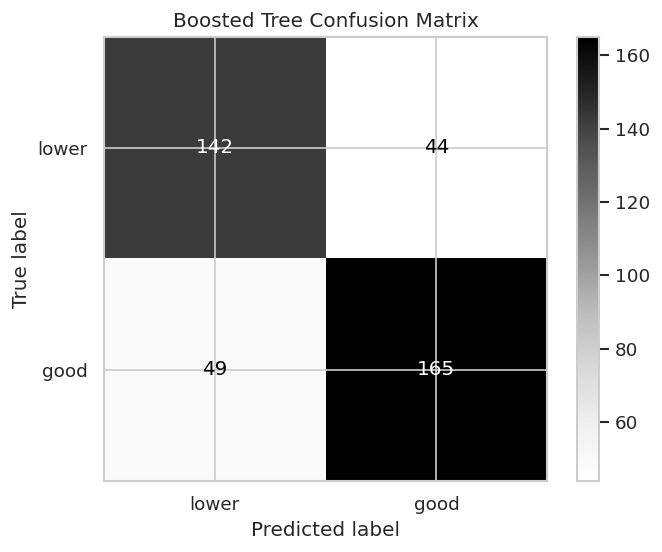

In [3]:
X = df.drop(columns=["quality", "good_quality"])
y = df["good_quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

if HAS_XGBOOST:
    model = XGBClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE,
    )
else:
    model = HistGradientBoostingClassifier(
        learning_rate=0.06,
        max_iter=250,
        max_leaf_nodes=15,
        random_state=RANDOM_STATE,
    )

model.fit(X_train, y_train)
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(type(model).__name__)
print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
print(f"ROC AUC:  {roc_auc_score(y_test, proba):.3f}")
print(classification_report(y_test, pred, target_names=["lower quality", "good quality"]))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["lower", "good"], cmap="Greys")
plt.title("Boosted Tree Confusion Matrix")
plt.show()

,feature,importance
10,alcohol,0.245853
9,sulphates,0.132945
1,volatile acidity,0.104950
6,total sulfur dioxide,0.101752
0,fixed acidity,0.071768
7,density,0.067717
4,chlorides,0.060324
8,pH,0.058652
5,free sulfur dioxide,0.054510
3,residual sugar,0.050777


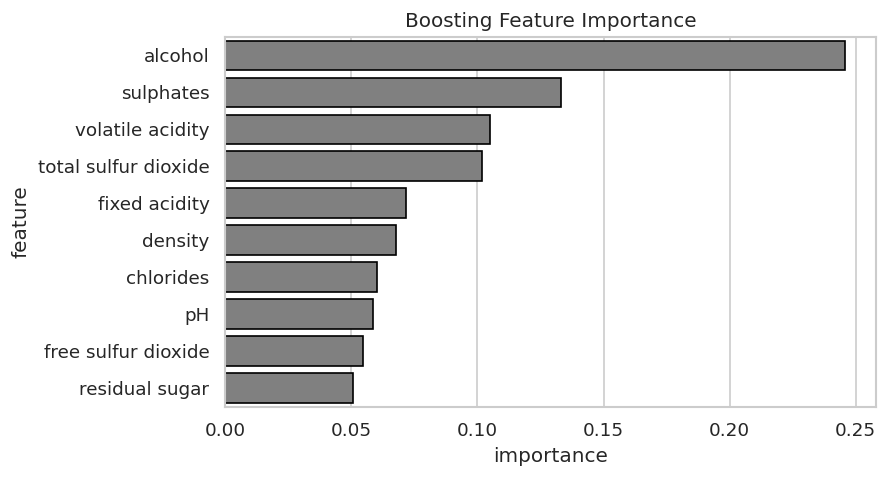

In [4]:
if HAS_XGBOOST:
    importance = pd.DataFrame(
        {"feature": X.columns, "importance": model.feature_importances_}
    ).sort_values("importance", ascending=False)
else:
    result = permutation_importance(
        model, X_test, y_test, n_repeats=8, random_state=RANDOM_STATE, n_jobs=-1
    )
    importance = pd.DataFrame(
        {"feature": X.columns, "importance": result.importances_mean}
    ).sort_values("importance", ascending=False)

display(importance)
plt.figure(figsize=(7, 4))
sns.barplot(data=importance.head(10), x="importance", y="feature", color="gray", edgecolor="black")
plt.title("Boosting Feature Importance")
plt.show()